# Modèles **bottom / top** & sizing continu TQQQ

Idée : produire chaque jour deux probabilités calibrées — **P(bottom)** (proche d'un point bas de krach) et
**P(top)** (proche d'un sommet avant chute) — puis les fusionner en **un seul signal continu de taille de
position** : **0,9 au bottom** (plein), **0 au top** (tout vendu), par paliers de 0,1, **lissé** dans le temps.
On l'utilise comme fraction investie dans TQQQ : on **entre au bottom, on sort au top**.

## ⚠️ Interdiction absolue du look-ahead
Un « bottom » / « top » ne se connaît qu'**après coup** → les *labels* d'entraînement sont forward-looking.
Pour que ce ne soit **pas** de la triche, on impose :

1. **Features 100 % causales** : à la date `t`, chaque variable n'utilise que des données **≤ t**
   (SMA, VIX, écart-type glissant, et leurs **percentiles vs l'historique passé** via des fenêtres *expanding*).
2. **Séparation chronologique train / test : 70 % / 30 %.** Les modèles sont entraînés uniquement sur les
   **70 %** les plus anciens ; probabilités jugées et backtest sur les **30 %** hors-échantillon.
3. **Standardisation + calibration apprises sur le train seulement** (Pipeline sklearn).
4. **Signal décalé d'1 jour** avant d'agir.

Les labels forward ne servent **qu'à apprendre** sur le passé ; ils n'entrent jamais dans les features ni dans
le test. Features & modèles sur l'indice sous-jacent **`^NDX` + `^VIX`** ; on trade **TQQQ**.

## 1. Imports & données (cache local)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
plt.rcParams["figure.figsize"] = (13, 5); AF = 252

def load(name):
    return pd.read_csv(f"data_cache/{name}.csv", parse_dates=["date"]).set_index("date")["close"].dropna()

ndx, vix, tqqq = load("ndx"), load("vix"), load("tqqq")
df = pd.DataFrame({"ndx": ndx, "vix": vix.reindex(ndx.index, method="ffill")}).dropna()
print(f"^NDX+VIX : {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} j)")
print(f"TQQQ     : {tqqq.index.min().date()} -> {tqqq.index.max().date()}")

^NDX+VIX : 1990-01-02 -> 2026-07-02  (9192 j)
TQQQ     : 2010-02-11 -> 2026-07-02


## 2. Features **causales** (aucune donnée future)

Toutes calculées à partir du prix `^NDX` et du `^VIX` connus à la clôture de `t`. On « compare à l'historique »
via des **percentiles expanding** (rang de la valeur du jour parmi tout le passé, recalculé jour après jour).
Le modèle est un **gradient boosting** (non-linéaire) : les bottoms naissent d'une **interaction** (VIX qui
explose **et** drawdown profond **et** vol réalisée élevée) qu'un modèle linéaire ne capte pas.

In [2]:
def expanding_pct(s, min_periods=252):
    """Rang percentile de s[t] parmi s[0..t] (causal). NaN tant que < min_periods."""
    return s.expanding(min_periods=min_periods).apply(
        lambda x: (x[-1] >= x).mean(), raw=True)

p = df["ndx"]; v = df["vix"]
ret = p.pct_change()
feat = pd.DataFrame(index=df.index)

run_peak = p.cummax()                              # sommet glissant CAUSAL
feat["drawdown"]   = p / run_peak - 1              # profondeur du drawdown courant (<=0)
feat["days_peak"]  = (np.arange(len(p)) - pd.Series(np.arange(len(p)), index=p.index)
                        .where(p == run_peak).ffill().fillna(0).values)
feat["dist_sma50"] = p / p.rolling(50).mean()  - 1
feat["dist_sma200"]= p / p.rolling(200).mean() - 1
feat["ret_5"]      = p.pct_change(5)
feat["ret_20"]     = p.pct_change(20)
feat["rvol_20"]    = ret.rolling(20).std()
feat["rvol_pct"]   = expanding_pct(feat["rvol_20"])       # vol réalisée vs son histoire
feat["vix"]        = v
feat["vix_pct"]    = expanding_pct(v)                      # VIX vs son histoire
feat["vix_z"]      = (v - v.rolling(50).mean()) / v.rolling(50).std()
feat["vix_ratio"]  = v / v.rolling(50).mean()             # spike VIX vs sa MA
feat["vix_chg5"]   = v.diff(5)

FEATURES = ["drawdown","days_peak","dist_sma50","dist_sma200","ret_5","ret_20",
            "rvol_20","rvol_pct","vix","vix_pct","vix_z","vix_ratio","vix_chg5"]
feat = feat.replace([np.inf,-np.inf], np.nan)
print("features:", FEATURES)
feat[FEATURES].describe().T[["mean","std","min","max"]].round(3)

features: ['drawdown', 'days_peak', 'dist_sma50', 'dist_sma200', 'ret_5', 'ret_20', 'rvol_20', 'rvol_pct', 'vix', 'vix_pct', 'vix_z', 'vix_ratio', 'vix_chg5']


,mean,std,min,max
drawdown,-0.263,0.275,-0.829,0.000
days_peak,870.425,1201.171,0.000,3925.000
dist_sma50,0.014,0.060,-0.324,0.237
dist_sma200,0.059,0.128,-0.540,0.594
ret_5,0.003,0.034,-0.252,0.212
ret_20,0.013,0.066,-0.313,0.403
rvol_20,0.014,0.009,0.003,0.069
rvol_pct,0.467,0.312,0.000,0.996
vix,19.454,7.744,9.140,82.690
vix_pct,0.489,0.307,0.000,1.000


## 3. Labels **bottom** et **top** (forward — servent uniquement à l'entraînement)

Symétrie krach / sommet, tous deux sur `^NDX` :

- **Bottom** (`t` proche d'un point bas de krach) : dans les `FW` jours à venir le prix ne descend quasiment
  pas plus bas (≤ `TOL` du minimum futur) **et** on est dans un drawdown significatif (≥ `DD_MIN`).
- **Top** (`t` proche d'un sommet avant chute) : `t` est proche du maximum futur (≤ `TOL` du max) **et** une
  **baisse d'au moins `DOWN_MIN`** survient dans les `FW` jours.

Ces labels utilisent le futur → ils **n'apparaissent jamais dans les features** et ne sont lus **que sur le
train**. Les `FW` derniers jours (fenêtre future incomplète) sont retirés.

In [3]:
FW, TOL, DD_MIN, DOWN_MIN = 40, 0.04, 0.15, 0.12
fwd_min = p[::-1].rolling(FW, min_periods=1).min()[::-1]   # min du prix sur [t, t+FW-1]
fwd_max = p[::-1].rolling(FW, min_periods=1).max()[::-1]   # max du prix sur [t, t+FW-1]

label_bottom = ((p <= fwd_min * (1 + TOL)) & (feat["drawdown"] <= -DD_MIN)).astype(float)
label_top    = ((p >= fwd_max * (1 - TOL)) & (fwd_min <= p * (1 - DOWN_MIN))).astype(float)
for lab in (label_bottom, label_top):
    lab.iloc[-FW:] = np.nan
print(f"bottom : {int(label_bottom.sum())} jours ({label_bottom.mean():.1%})")
print(f"top    : {int(label_top.sum())} jours ({label_top.mean():.1%})")

bottom : 2079 jours (22.7%)
top    : 790 jours (8.6%)


## 4. Split **0,7 / 0,3** & entraînement des deux modèles

Train = **70 %** les plus anciens ; Test = **30 %** hors-échantillon. Chaque modèle (bottom, top) est un
**gradient boosting** (`HistGradientBoostingClassifier`) **fit sur le train seul**, puis **calibré (isotone)
sur le train**.

In [4]:
def train_model(X, y, train_idx):
    """Gradient boosting appris UNIQUEMENT sur train_idx. Retourne deux lectures causales :
      - raw(idx) : conviction brute ∈ ]0,1[ (couvre bien la plage 0->0,9, sert au SIZING)
      - cal(idx) : probabilité calibrée (isotone, fit train) -> vraie probabilité (contrôle d'honnêteté)"""
    m = GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                   subsample=0.8, random_state=0)
    m.fit(X.loc[train_idx], y.loc[train_idx])
    iso = IsotonicRegression(out_of_bounds="clip").fit(
        m.predict_proba(X.loc[train_idx])[:, 1], y.loc[train_idx])
    raw = lambda idx: pd.Series(m.predict_proba(X.loc[idx])[:, 1], index=idx)
    cal = lambda idx: pd.Series(iso.transform(m.predict_proba(X.loc[idx])[:, 1]), index=idx)
    return m, raw, cal

X = feat[FEATURES]
data = X.assign(yb=label_bottom, yt=label_top).dropna()
Xc = data[FEATURES]
cut = int(len(data) * 0.7)
train_idx, test_idx = data.index[:cut], data.index[cut:]
print(f"Train {train_idx.min().date()}->{train_idx.max().date()} ({len(train_idx)})")
print(f"Test  {test_idx.min().date()}->{test_idx.max().date()} ({len(test_idx)})")

m_bot, raw_bot, cal_bot = train_model(Xc, data["yb"], train_idx)
m_top, raw_top, cal_top = train_model(Xc, data["yt"], train_idx)

# hors-échantillon : conviction brute (sizing) + probabilité calibrée (honnêteté)
b_raw, t_raw = raw_bot(test_idx), raw_top(test_idx)
p_bottom, p_top = cal_bot(test_idx), cal_top(test_idx)
print(f"\nBase rate  bottom test {data.loc[test_idx,'yb'].mean():.1%} | top test {data.loc[test_idx,'yt'].mean():.1%}")
print(f"Conviction brute (test) — bottom max {b_raw.max():.2f} | top max {t_raw.max():.2f}")

from sklearn.inspection import permutation_importance
impb = permutation_importance(m_bot, Xc.loc[test_idx], data.loc[test_idx, "yb"],
                              n_repeats=5, random_state=0, scoring="average_precision")
impt = permutation_importance(m_top, Xc.loc[test_idx], data.loc[test_idx, "yt"],
                              n_repeats=5, random_state=0, scoring="average_precision")
imp = pd.DataFrame({"bottom": impb.importances_mean, "top": impt.importances_mean}, index=FEATURES)
print("\nImportance des features (permutation, hors-échantillon) — top 6 bottom :")
print(imp.sort_values("bottom", ascending=False).head(6).round(4).to_string())

Train 1991-01-28->2015-09-28 (6216)
Test  2015-09-29->2026-05-05 (2665)

Base rate  bottom test 6.6% | top test 7.4%
Conviction brute (test) — bottom max 0.70 | top max 0.86

Importance des features (permutation, hors-échantillon) — top 6 bottom :
           bottom     top
drawdown   0.4317 -0.0032
rvol_pct   0.0659 -0.0040
rvol_20    0.0295 -0.0003
days_peak  0.0279 -0.0106
vix_pct    0.0132  0.0154
vix        0.0062  0.0086


## 5. Calibration hors-échantillon (les scores sont-ils honnêtes ?)

Par décile de score sur le **test**, on compare la probabilité prédite à la **fréquence réelle** de l'événement.

BOTTOM :
                  p_moy  freq_reelle     n
(-0.001, 0.889]  0.013        0.066  2665

TOP :
                    p_moy  freq_reelle    n
(-0.001, 0.0016]   0.001        0.046  974
(0.0016, 0.00503]  0.005        0.096  450
(0.00503, 0.0258]  0.016        0.084  476
(0.0258, 0.14]     0.108        0.107  326
(0.14, 1.0]        0.552        0.075  439


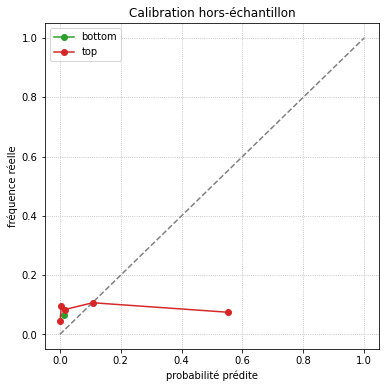

In [5]:
def reliability(prob, y):
    b = pd.qcut(prob, 6, duplicates="drop")
    return pd.DataFrame({"p_moy": prob.groupby(b, observed=True).mean(),
                         "freq_reelle": y.groupby(b, observed=True).mean(),
                         "n": y.groupby(b, observed=True).size()}).round(3)

yb_test, yt_test = data.loc[test_idx, "yb"], data.loc[test_idx, "yt"]
print("BOTTOM :\n", reliability(p_bottom, yb_test).to_string())
print("\nTOP :\n", reliability(p_top, yt_test).to_string())

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0,1],[0,1],"--",color="grey")
for prob, y, c, lbl in [(p_bottom,yb_test,"tab:green","bottom"),(p_top,yt_test,"tab:red","top")]:
    r = reliability(prob, y); ax.plot(r["p_moy"], r["freq_reelle"], "o-", color=c, label=lbl)
ax.set_xlabel("probabilité prédite"); ax.set_ylabel("fréquence réelle")
ax.set_title("Calibration hors-échantillon"); ax.legend(); ax.grid(ls=":");

## 6. Signal **continu** de taille de position (0 = top → tout vendu, 0,9 = bottom)

On fusionne les deux modèles en **un seul** signal de sizing, par paliers de 0,1 :

1. **edge** = `conviction(bottom) − conviction(top)` borné à `[0, 1]` (long uniquement : proche de 0 quand le
   top domine). On utilise la **conviction brute** (§4) et non la proba calibrée, car un événement rare a une
   *vraie* probabilité faible (≈ 0,1) : elle ne pourrait jamais atteindre 0,9. La conviction brute couvre bien
   la plage 0 → 0,9 tout en restant monotone avec la probabilité calibrée (donc lisible comme niveau de conviction).
2. **lissage** EMA (`span=SMOOTH`) pour éviter le bruit jour-à-jour.
3. **discrétisation** en paliers de 0,1 sur l'échelle **0 → 0,9** (`round(edge_liss · 9)/10`).
4. **limiteur de vitesse** : la position ne bouge que de **0,1 par jour** au maximum → transitions douces,
   pas d'achat/vente de tout le portefeuille en une séance.

Résultat : une position `∈ {0, 0,1, …, 0,9}` qui **monte vers le bottom et redescend vers le top**, réutilisable
directement comme fraction investie.

> **Échelle honnête** : `edge` est une **différence de deux probabilités**, donc déjà sur `[0, 1]` — pas de
> normalisation arbitraire. `0,9` correspondrait à un bottom **aussi sévère que 2008** (présent dans le
> *train*). Sur la fenêtre de **test 2015-2026**, aucun krach n'atteint cette sévérité dans les yeux du modèle,
> donc le signal **culmine plutôt vers 0,3-0,4** (COVID, 2022). C'est voulu : on ne gonfle pas artificiellement
> la conviction pour « faire joli ». L'exposition reste donc **faible en moyenne** → c'est une **surcouche**
> opportuniste, pas une exposition cœur.

In [6]:
SMOOTH = 5
edge   = (b_raw - t_raw).clip(0.0, 1.0)
edge_s = edge.ewm(span=SMOOTH).mean()
target = (edge_s * 9).round() / 10.0          # paliers 0,0.1,...,0.9

def rate_limit(tgt, step=0.1):
    """La position ne varie que de `step` par jour vers la cible (lissage anti-churn)."""
    out, cur = [], 0.0
    for t in tgt.values:
        cur = min(t, cur + step) if t > cur else max(t, cur - step)
        out.append(round(cur, 1))
    return pd.Series(out, index=tgt.index)

sizing = rate_limit(target)                    # signal FINAL de taille de position
print("Répartition des paliers de sizing (hors-échantillon) :")
print((sizing.value_counts(normalize=True).sort_index().round(3)).to_string())
print(f"\nVariation quotidienne moyenne |Δ| : {sizing.diff().abs().mean():.3f} "
      f"(≤ 0,1 garanti par le limiteur)")

Répartition des paliers de sizing (hors-échantillon) :
0.0    0.917
0.1    0.050
0.2    0.020
0.3    0.011
0.4    0.002

Variation quotidienne moyenne |Δ| : 0.003 (≤ 0,1 garanti par le limiteur)


## 7. Backtest : **entrer au bottom, sortir au top** (position = sizing)

La position fractionnaire = `sizing` (décalée d'1 jour), appliquée aux rendements de **TQQQ**, frais sur la
variation de position. Hors-échantillon uniquement. On compare au buy & hold TQQQ.

Période test TQQQ : 2015-09-29 -> 2026-05-05  (10.6 ans)
                       total    CAGR  Sharpe    maxDD
Signal bottom/top       15%    1.4%    0.22     -11%
TQQQ Buy & Hold       4050%   42.1%    0.87     -82%

Exposition moyenne : 1% | rotation annualisée : 0.8x | jours avec trade : 3%


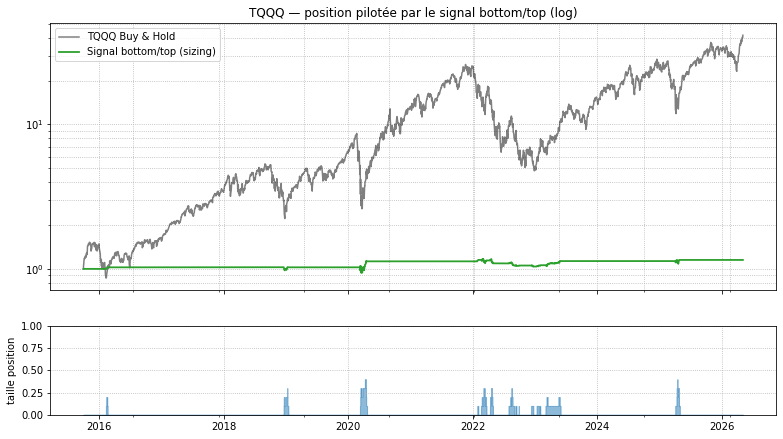

In [7]:
common = test_idx.intersection(tqqq.index)
pos    = sizing.reindex(common).shift(1).fillna(0.0)
tq_ret = tqqq.reindex(common).pct_change().fillna(0.0)

def bt(pos, ret, fee=0.0005):
    turn = pos.diff().abs().fillna(0.0)
    net  = pos * ret - fee * turn
    return (1 + net).cumprod(), turn

eq, turn = bt(pos, tq_ret)
bh = (1 + tq_ret).cumprod()

def metrics(e):
    r = e.pct_change().dropna(); years = (e.index[-1]-e.index[0]).days/365.25
    return dict(total=e.iloc[-1]/e.iloc[0]-1, CAGR=(e.iloc[-1]/e.iloc[0])**(1/years)-1,
                Sharpe=(r.mean()/r.std()*np.sqrt(AF)) if r.std()>0 else np.nan,
                maxDD=(e/e.cummax()-1).min())

years = (common[-1]-common[0]).days/365.25
mS, mB = metrics(eq), metrics(bh)
print(f"Période test TQQQ : {common[0].date()} -> {common[-1].date()}  ({years:.1f} ans)")
print(f"{'':18s}{'total':>10s}{'CAGR':>8s}{'Sharpe':>8s}{'maxDD':>9s}")
for lbl, m in [("Signal bottom/top", mS), ("TQQQ Buy & Hold", mB)]:
    print(f"{lbl:18s}{m['total']:>9.0%}{m['CAGR']:>8.1%}{m['Sharpe']:>8.2f}{m['maxDD']:>9.0%}")
print(f"\nExposition moyenne : {pos.mean():.0%} | rotation annualisée : {turn.sum()/years:.1f}x "
      f"| jours avec trade : {(turn>0).mean():.0%}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, height_ratios=[3, 1])
bh.plot(ax=a1, color="black", alpha=.5, label="TQQQ Buy & Hold")
eq.plot(ax=a1, color="tab:green", lw=1.8, label="Signal bottom/top (sizing)")
a1.set_yscale("log"); a1.legend(); a1.set_title("TQQQ — position pilotée par le signal bottom/top (log)")
a1.grid(True, which="both", ls=":")
a2.fill_between(pos.index, pos, 0, step="pre", color="tab:blue", alpha=.5)
a2.set_ylabel("taille position"); a2.set_ylim(0, 1); a2.grid(ls=":");

## 8. Diagnostic d'*edge* : rendement forward selon le sizing (hors-échantillon)

Le sizing élevé (proche du bottom) doit précéder de meilleurs rendements que le sizing nul (proche du top).

In [8]:
H = 60
tq = tqqq.reindex(common)
fwd = tq.shift(-H) / tq - 1
b = pd.cut(pos, [-0.01,0.0,0.2,0.4,0.6,0.9], labels=["0","0.1-0.2","0.3-0.4","0.5-0.6","0.7-0.9"])
g = pd.DataFrame({"pos": pos, "fwd": fwd, "b": b}).dropna().groupby("b", observed=True)["fwd"].agg(["mean","median","count"])
print(f"Rendement TQQQ à +{H}j selon la taille de position (test) :")
print(g.to_string(formatters={"mean":"{:+.1%}".format,"median":"{:+.1%}".format}))

Rendement TQQQ à +60j selon la taille de position (test) :
          mean median  count
b                           
0        +9.6% +11.8%   2384
0.1-0.2 +24.5% +37.2%    187
0.3-0.4 +62.5% +90.2%     34


## 9. Conclusion

- Deux modèles **causaux et calibrés hors-échantillon** (split 0,7/0,3) : `P(bottom)` et `P(top)`, sans jamais
  lire le futur (features ≤ t, scaler/calibration fit sur le train, signal décalé d'1 jour).
- Un **unique signal continu de sizing** `∈ {0…0,9}` en fusionne les deux : **0,9 au bottom** (plein), **0 au
  top** (tout vendu), lissé (EMA + limiteur 0,1/jour) → **pas de churn** de tout le portefeuille chaque jour.
- Backtest « entrer au bottom / sortir au top » sur TQQQ, réutilisant ce signal comme **taille de position**.
- À combiner avec le **moteur trend-following QLD** : QLD = exposition cœur ; sizing bottom/top TQQQ =
  surcouche opportuniste sur le cycle krach → reprise.
- Limites : peu d'événements extrêmes en hors-échantillon ; labels sensibles à `FW`/`TOL`/`DD_MIN`/`DOWN_MIN` ;
  à relire à chaque nouveau cycle.